In [2]:
import numpy as np

In [3]:
import pandas as pd 

In [5]:
import matplotlib.pyplot as plt

In [6]:
import seaborn as sns

In [ ]:
from scipy.stats import ttest_ind

In [ ]:
np.random.seed(42)

control_sales = np.random.normal(
    loc=100,
    scale=15,
    size=100
)

treatment_sales = np.random.normal(
    loc=110,
    scale=15,
    size=100
)

In [ ]:
print(control_sales[:10])
print(treatment_sales[:10])

[107.4507123   97.92603548 109.71532807 122.84544785  96.48769938
  96.48794565 123.68819223 111.51152094  92.95788421 108.13840065]


In [16]:
control_df = pd.DataFrame({
    "group": "control",
    "sales": control_sales
})

treatment_df = pd.DataFrame({
    "group": "treatment",
    "sales": treatment_sales
})

df = pd.concat(
    [control_df, treatment_df],
    ignore_index=True
)

df.head()

,group,sales
0,control,107.450712
1,control,97.926035
2,control,109.715328
3,control,122.845448
4,control,96.487699


In [17]:
df.groupby("group")["sales"].agg([
    "mean",
    "median",
    "var",
    "std"
])

,mean,median,var,std
group,,,,
control,98.442302,98.095656,185.573226,13.622526
treatment,110.334569,111.261608,204.634012,14.305034


In [18]:
control_mean = df[
    df["group"] == "control"
]["sales"].mean()

treatment_mean = df[
    df["group"] == "treatment"
]["sales"].mean()

print("Control mean:", control_mean)
print("Treatment mean:", treatment_mean)
print(
    "Difference:",
    treatment_mean - control_mean
)

Control mean: 98.44230223908859
Treatment mean: 110.33456880574886
Difference: 11.892266566660268


In [19]:
from scipy.stats import ttest_ind

In [20]:
t_stat, p_value = ttest_ind(
    control_sales,
    treatment_sales
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -6.020283943419771
P-value: 8.314432515207102e-09


In [22]:
if p_value < 0.05:
    print("Reject H0")
    print("There is a statistically significant difference.")
else:
    print("Do not reject H0")
    print("There is not enough evidence of a statistically significant difference.")

Reject H0
There is a statistically significant difference.


In [27]:
print(f"Control average sales: {control_mean:.2f}")
print(f"Treatment average sales: {treatment_mean:.2f}")
print(f"Difference: {treatment_mean - control_mean:.2f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print(
        "Conclusion: The difference between the two groups "
        "is statistically significant."
    )
else:
    print(
        "Conclusion: We do not have enough evidence "
        "to conclude that the groups differ."
    )

Control average sales: 98.44
Treatment average sales: 110.33
Difference: 11.89
P-value: 8.3144e-09
Conclusion: The difference between the two groups is statistically significant.


In [28]:
improvement = (
    (treatment_mean - control_mean)
    / control_mean
) * 100

print(f"Sales improvement: {improvement:.2f}%")

Sales improvement: 12.08%


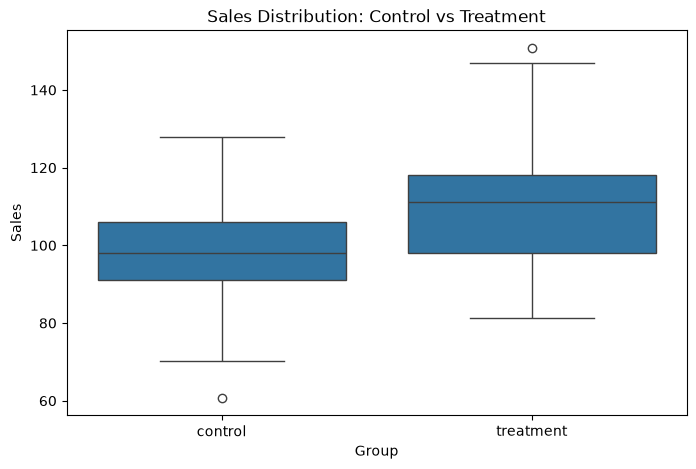

In [30]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="group",
    y="sales"
)

plt.title("Sales Distribution: Control vs Treatment")
plt.xlabel("Group")
plt.ylabel("Sales")

plt.show()

In [32]:
control_df = pd.DataFrame({
    "group": "control",
    "sales": control_sales
})

treatment_df = pd.DataFrame({
    "group": "treatment",
    "sales": treatment_sales
})

df = pd.concat(
    [control_df, treatment_df],
    ignore_index=True
)

df

,group,sales
0,control,107.450712
1,control,97.926035
2,control,109.715328
3,control,122.845448
4,control,96.487699
...,...,...
195,treatment,115.779761
196,treatment,96.742138
197,treatment,112.305877
198,treatment,110.873131
